In [9]:
import yfinance as yf
apple = yf.Ticker('AAPL')

apple_data = apple.history(start='2010-01-01', end='2021-01-01')

print(apple_data.head())
apple_data.isna().sum()

                               Open      High       Low     Close     Volume  \
Date                                                                           
2010-01-04 00:00:00-05:00  6.395005  6.427066  6.363544  6.412384  493729600   
2010-01-05 00:00:00-05:00  6.430062  6.459725  6.389611  6.423470  601904800   
2010-01-06 00:00:00-05:00  6.423470  6.448938  6.314704  6.321296  552160000   
2010-01-07 00:00:00-05:00  6.344668  6.352159  6.263768  6.309611  477131200   
2010-01-08 00:00:00-05:00  6.301222  6.352159  6.264068  6.351560  447610800   

                           Dividends  Stock Splits  
Date                                                
2010-01-04 00:00:00-05:00        0.0           0.0  
2010-01-05 00:00:00-05:00        0.0           0.0  
2010-01-06 00:00:00-05:00        0.0           0.0  
2010-01-07 00:00:00-05:00        0.0           0.0  
2010-01-08 00:00:00-05:00        0.0           0.0  


Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [6]:
import pandas as pd

clean_data = apple_data.dropna()
filled_data = apple_data.fillna(method='ffill')
imputed_data = apple_data.fillna(apple_data.mean())



C:\Users\MPIT\AppData\Local\Temp\ipykernel_20148\4170458707.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data = apple_data.fillna(method='ffill')


In [8]:
from scipy import stats
z_scores = stats.zscore(apple_data['Close'])
filtered_data = apple_data[abs(z_scores)<3]

q1 = apple_data['Close'].quantile(0.25)
q3 = apple_data['Close'].quantile(0.75)
IQR = q3 - q1

outlier_removed_data = apple_data[~((apple_data['Close']<(q1-1.5*IQR))| (apple_data['Close']>(q3+1.5*IQR)))]

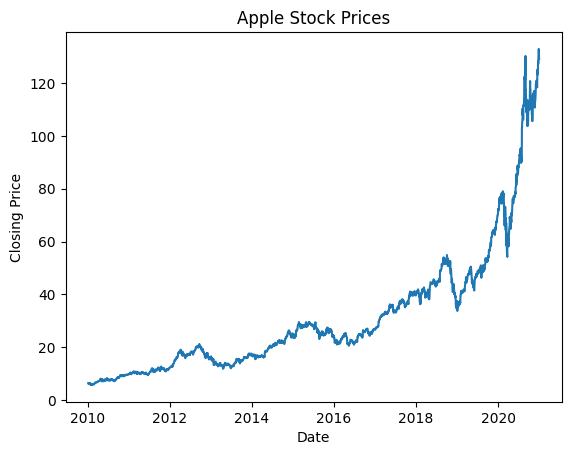

In [12]:
import matplotlib.pyplot as plt

plt.plot(apple_data.index, apple_data['Close'])
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Apple Stock Prices')
plt.show()

c:\Users\MPIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


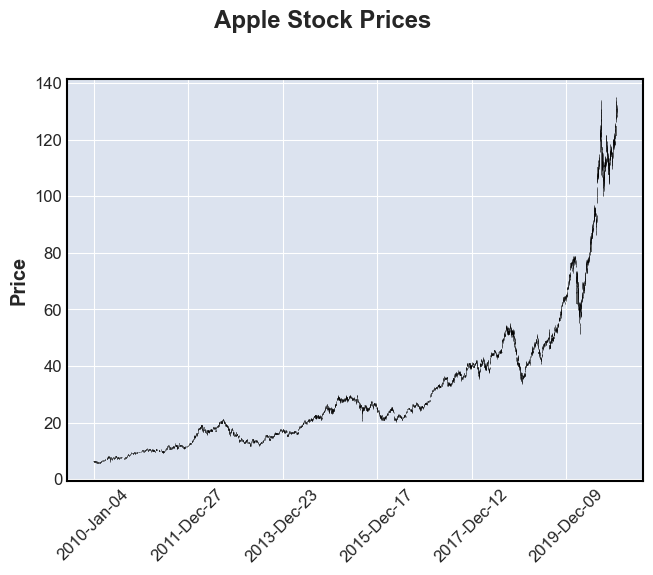

In [13]:
import mplfinance as mpf
mpf.plot(apple_data, type='candlestick', title='Apple Stock Prices')

              Open         High          Low        Close        Volume  \
count  2769.000000  2769.000000  2769.000000  2769.000000  2.769000e+03   
mean     31.224989    31.550729    30.899574    31.238050  2.866162e+08   
std      24.350784    24.679910    24.014436    24.361712  2.289459e+08   
min       5.763983     5.872748     5.700461     5.754396  4.544800e+07   
25%      15.003487    15.169545    14.888316    15.045027  1.211120e+08   
50%      24.363291    24.613833    24.075359    24.296839  2.029972e+08   
75%      40.491991    40.839976    40.243345    40.510780  3.890376e+08   
max     134.259471   134.979143   130.651332   132.936813  1.880998e+09   

         Dividends  Stock Splits  
count  2769.000000   2769.000000  
mean      0.001815      0.003973  
std       0.016744      0.153189  
min       0.000000      0.000000  
25%       0.000000      0.000000  
50%       0.000000      0.000000  
75%       0.000000      0.000000  
max       0.205000      7.000000  


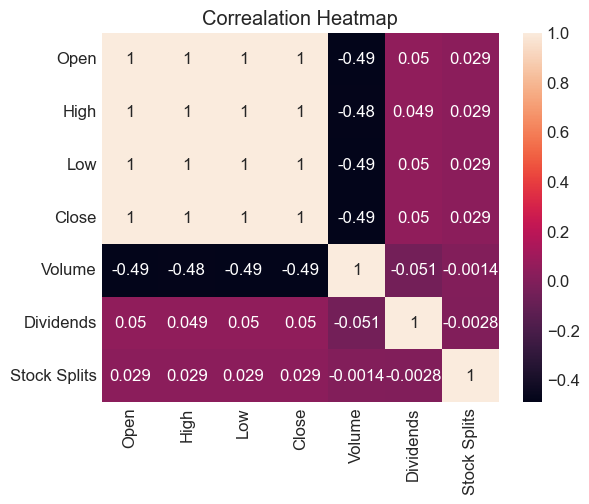

In [15]:
import seaborn as sns
correlation_matrix = apple_data.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correalation Heatmap")
descriptive_stats = apple_data.describe()
print(descriptive_stats)

In [18]:
from scipy import stats
before_event = apple_data.loc[apple_data.index<'2020-01-01',"Close"]
after_event = apple_data.loc[apple_data.index>='2020-01-01','Close']
t_statistic, p_value = stats.ttest_ind(before_event, after_event)
print('T-statistic:', t_statistic)
print('P-value:',p_value)

T-statistic: -69.34330932585499
P-value: 0.0


In [19]:
import statsmodels.api as sm

X = apple_data[['Volume']]
y=apple_data['Close']
X= sm.add_constant(X)
model = sm.OLS(y, X).fit()
print("intercept:", model.params[0])
print('Coefficient:', model.params[1])
model.summary()

intercept: 46.11535680456785
Coefficient: -5.1906727741382295e-08


C:\Users\MPIT\AppData\Local\Temp\ipykernel_20148\2634669327.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("intercept:", model.params[0])
C:\Users\MPIT\AppData\Local\Temp\ipykernel_20148\2634669327.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Coefficient:', model.params[1])


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     864.0
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.63e-165
Time:                        12:00:40   Log-Likelihood:                -12394.
No. Observations:                2769   AIC:                         2.479e+04
Df Residuals:                    2767   BIC:                         2.480e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.1154      0.648     71.195      0.000      44.845      47.385
Volume     -5.191e-08   1.77e-09    -29.394      0.000   -5.54e-08   -4.84e-08
==============================================================================
Omnibus:                     1195.050   Durbin-Watson:                   0.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4872.247
Skew:                           2.144   Prob(JB):                         0.00
Kurtosis:                       7.883   Cond. No.                     5.88e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.88e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [22]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(apple_data['Close'], order=(1,0,0))
results = model.fit()
predictions = results.predict(start='2021-01-02', end='2021-01-10')
print(predictions)

c:\Users\MPIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MPIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MPIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MPIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting au

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'